          施設名                            施設名(英語)    カテゴリ          電話番号  \
0       品川区役所              Shinagawa City Office     区役所  03-3777-1111   
1  品川第一地域センター  Shinagawa Dai-ichi Community Ctr.  地域センター  03-3450-2000   
2  品川第二地域センター    Shinagawa Dai-ni Community Ctr.  地域センター  03-3472-2000   
3  大崎第一地域センター      Osaki Dai-ichi Community Ctr.  地域センター  03-3491-2000   
4  大崎第二地域センター        Osaki Dai-ni Community Ctr.  地域センター  03-3492-2000   

       郵便番号                住所         緯度         経度  \
0  140-0005    東京都品川区広町2-1-36  35.608837  139.73024   
1  140-0001  東京都品川区北品川3-11-16  35.616681  139.74008   
2  140-0004   東京都品川区南品川5-3-20  35.611373  139.74129   
3  141-0031   東京都品川区西五反田3-6-3  35.627776  139.71686   
4  141-0032     東京都品川区大崎2-9-4  35.616945  139.72757   

                     geometry  
0  POINT (139.73024 35.60884)  
1  POINT (139.74008 35.61668)  
2  POINT (139.74129 35.61137)  
3  POINT (139.71686 35.62778)  
4  POINT (139.72757 35.61694)  
データの件数: 756 件


<Axes: >

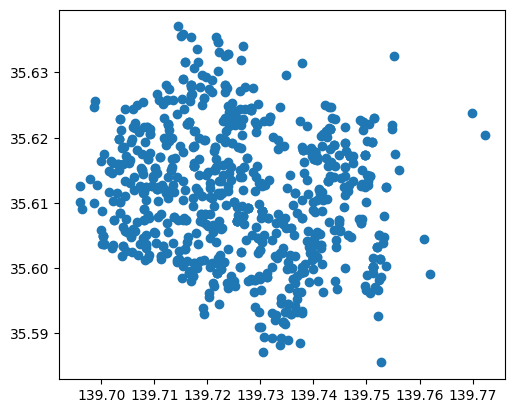

In [1]:
import pandas as pd
df = pd.read_csv("../data/kokyoshisetsu_edit.csv", encoding="cp932")
#df

import geopandas as gpd

df = df.loc[:, "施設名":"経度"]
geometry = gpd.points_from_xy(df['経度'], df['緯度'])
gdf = gpd.GeoDataFrame(df, geometry=geometry)
#gdf
gdf.crs=6668

# 最初の5行を表示
print(gdf.head())

# 行数と列数を確認
print(f"データの件数: {len(gdf)} 件")

gdf.plot()

## マーカーの設置

In [ ]:
import folium
from IPython.display import display, IFrame 

# 品川駅　緯度経度
lat = 35.6291112
lon = 139.7389313

map = folium.Map(location=[lat, lon], zoom_start=13)

#choroplethで可視化
folium.Choropleth(
    gdf
).add_to(map)

map

#map.save("my_map.html")

#import webbrowser
#import os
#webbrowser.open('file://' + os.path.realpath("my_map.html"))


### ヒートマップの作製

In [7]:
import folium
from folium.plugins import HeatMap

#品川駅　緯度経度
lat = 35.6291112
lon = 139.7389313

map = folium.Map(location=[lat, lon], zoom_start=13)

pointlist = []
for index, row in df.iterrows():
    pointlist.append((row.緯度, row.経度))

HeatMap(pointlist, radius=20, blur=5).add_to(map)
map

#map.save("my_map.html")

#import webbrowser
#import os
#webbrowser.open('file://' + os.path.realpath("my_map.html"))

### ルート生成

In [ ]:
import folium



# 経路の座標（緯度、経度）のリスト
route_coords = [
    (35.681236, 139.767125),  #東京駅
    (35.689487, 139.691711),  # 新宿駅
    (35.699739, 139.774219)   # 上野駅
]

# 地図の初期位置を経路の最初の地点に設定
map = folium.Map(location=route_coords[0], zoom_start=12)

pointlist = []
for index, row in df.iterrows():
    pointlist.append((row.緯度, row.経度))


#経路を描画（青色、太さ5)
folium.PolyLine(
    route_coords,
    #pointlist,
    color="blue",
    weight=5,
    opacity=0.8
).add_to(map)

#各地点にマーカーを追加
for idx, (lat, lon) in enumerate(route_coords, start=1):
    folium.Marker(
        location=(lat, lon),
        popup=f"Point {idx}"
    ).add_to(map)

map

In [ ]:
import folium
import openrouteservice
from openrouteservice import convert
import sys

def plot_route(api_key, start_coords, end_coords, output_html="route_map.html"):
    """
    Folium + OpenRouteServiceで経路を描画する関数
    :param api_key: OpenRouteService APIキー（文字列）
    :param start_coords: 出発地 (経度, 緯度) のタプル
    :param end_coords: 到着地 (経度, 緯度) のタプル
    :param output_html: 出力するHTMLファイル名
    """
    try:
        # APIクライアント作成
        client = openrouteservice.Client(key=api_key)

        # 経路取得（徒歩モード：'foot-walking', 車: 'driving-car'）
        route = client.directions(
            coordinates=[start_coords, end_coords],
            profile='driving-car',
            format='geojson'
        )
        # 中心座標を計算(出発地と到着地の中間)
        center_lat = (start_coords[1] + end_coords[1]) / 2
        center_lon = (start_coords[0] + end_coords[0]) / 2

        # Foliumマップ作製
        m = folium.Map(location=[center_lat, center_lon], zoom_start=13)

        # 経路を地図に追加
        folium.GeoJson(route, name="route").add_to(m)

        # 出発マーカー
        folium.Marker(
            location=[start_coords[1], start_coords[0]],
            popup="Start",
            icon=folium.Icon(color="green")
        ).add_to(m)

        # 到着マーカー
        folium.Marker(
            location=[end_coords[1], end_coords[0]],
            popup="End",
            icon=folium.Icon(color="red")
        ).add_to(m)

        # HTMLとして保存
        m.save(output_html)
        print(f"✅ 経路マップを '{output_html}' に保存しました。ブラウザで開いて確認してください。")
        
    except openrouteservice.exceptions.ApiError as e:
        print(f"APIエラー: {e}", file=sys.stderr)
    except Exception as e:
        print(f"エラーが発生しました: {e}", file=sys.stderr)

if __name__ == "__main__":
    #　ここに取得したAPIキーを入力
    API_KEY = "eyJvcmciOiI1YjNjZTM1OTc4NTExMTAwMDFjZjYyNDgiLCJpZCI6IjUzZTg5ZWNlMzFmYzQ4YTg4MjVhMWFkNDNlYjI4Y2UwIiwiaCI6Im11cm11cjY0In0="
    
    # 出発地と到着地（例: 東京駅 → 渋谷駅）
    start = (139.767125, 35.681236)  # 東京駅 (lon, lat)
    end = (139.701306, 35.658034)    # 渋谷駅 (lon, lat)

    plot_route(API_KEY, start, end)